In [ ]:
# Veriyi hazırla ve tabanı kur. Tiny Shakespeare'i oku, karakter tokenizer'ını yaz (encode, decode), veriyi %90 train, %10 val diye ayır. Rastgele parçalardan batch çeken get_batch fonksiyonunu yaz. Hafta 2'deki bigram modelini nn.Module olarak kur, eğit, val loss'u kaydet. Bu senin karşılaştırma tabanın. (7:52 - 38:00)

## Görev 1

In [15]:
import torch 
import torch.nn as nn
from torch.nn import functional as F

In [2]:
!wget https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt

--2026-10-02 15:07:42--  https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.108.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1115394 (1.1M) [text/plain]
Saving to: ‘input.txt’

input.txt           100%[===================>]   1.06M  2.33MB/s    in 0.5s    

2026-10-02 15:07:43 (2.33 MB/s) - ‘input.txt’ saved [1115394/1115394]



In [3]:
with open('input.txt', 'r', encoding='utf-8') as f:
    text = f.read()

In [4]:
print("length of dataset in characters: ", len(text))

length of dataset in characters:  1115394


In [5]:
print(text[:1000])

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor citizens, the patricians good.
What authority surfeits on would relieve us: if they
would yield us but the superfluity, while it were
wholesome, we might guess they relieved us humanely;
but they think we are too dear: the leanness that
afflicts us, the object of our misery, is as an
inventory to particularise their abundance; our
sufferance is a gain to them Let us revenge this with
our pikes, ere we become rakes: for the gods know I
speak this in hunger for bread, not in thirst for revenge.



In [6]:
chars = sorted(list(set(text)))
vocab_size = len(chars)
print(''.join(chars))
print(vocab_size)


 !$&',-.3:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz
65


In [ ]:
stoi = { ch:i for i,ch in enumerate(chars) }
itos = { i:ch for i,ch in enumerate(chars) }
encode = lambda s: [stoi[c] for c in s]  # encoder: take a string, output a list of integers
decode = lambda l: ''.join([itos[i] for i in l])  # decoder: take a list of integers, output a string

print(encode("hii there"))
print(decode(encode("hii there"))) 

[46, 47, 47, 1, 58, 46, 43, 56, 43]
hii there


In [ ]:
# hii there boşlukla birlikte tane sayı olması gerekiyor. örneğin boşluk 1, i 47 ile encode edilmiş ve bunları decode ile çözerek tekrar "hii there" yazdırıyor.

In [ ]:
# let's now encode the entire text dataset and store it into a torch.Tensor
data = torch.tensor(encode(text), dtype=torch.long)
print(data.shape, data.dtype)
print(data[:1000]) # the 1000 characters we looked at earier will to the GPT look like this

torch.Size([1115394]) torch.int64
tensor([18, 47, 56, 57, 58,  1, 15, 47, 58, 47, 64, 43, 52, 10,  0, 14, 43, 44,
        53, 56, 43,  1, 61, 43,  1, 54, 56, 53, 41, 43, 43, 42,  1, 39, 52, 63,
         1, 44, 59, 56, 58, 46, 43, 56,  6,  1, 46, 43, 39, 56,  1, 51, 43,  1,
        57, 54, 43, 39, 49,  8,  0,  0, 13, 50, 50, 10,  0, 31, 54, 43, 39, 49,
         6,  1, 57, 54, 43, 39, 49,  8,  0,  0, 18, 47, 56, 57, 58,  1, 15, 47,
        58, 47, 64, 43, 52, 10,  0, 37, 53, 59,  1, 39, 56, 43,  1, 39, 50, 50,
         1, 56, 43, 57, 53, 50, 60, 43, 42,  1, 56, 39, 58, 46, 43, 56,  1, 58,
        53,  1, 42, 47, 43,  1, 58, 46, 39, 52,  1, 58, 53,  1, 44, 39, 51, 47,
        57, 46, 12,  0,  0, 13, 50, 50, 10,  0, 30, 43, 57, 53, 50, 60, 43, 42,
         8,  1, 56, 43, 57, 53, 50, 60, 43, 42,  8,  0,  0, 18, 47, 56, 57, 58,
         1, 15, 47, 58, 47, 64, 43, 52, 10,  0, 18, 47, 56, 57, 58,  6,  1, 63,
        53, 59,  1, 49, 52, 53, 61,  1, 15, 39, 47, 59, 57,  1, 25, 39, 56, 41,
      

In [71]:
# Let's now split up the data into train and validation sets
n = int(0.9*len(data)) # first 90% will be train, rest val
train_data = data[:n]
val_data = data[n:]

In [72]:
block_size = 8
train_data[:block_size+1]

tensor([18, 47, 56, 57, 58,  1, 15, 47, 58])

In [73]:
x = train_data[:block_size]
y = train_data[1:block_size+1]
for t in range(block_size):
    context = x[:t+1]
    target = y[t]
    print(f"when input is {context} the target: {target}")

when input is tensor([18]) the target: 47
when input is tensor([18, 47]) the target: 56
when input is tensor([18, 47, 56]) the target: 57
when input is tensor([18, 47, 56, 57]) the target: 58
when input is tensor([18, 47, 56, 57, 58]) the target: 1
when input is tensor([18, 47, 56, 57, 58,  1]) the target: 15
when input is tensor([18, 47, 56, 57, 58,  1, 15]) the target: 47
when input is tensor([18, 47, 56, 57, 58,  1, 15, 47]) the target: 58


In [13]:
torch.manual_seed(1337)
batch_size = 4 # how many independent sequences will we process in parallel?
block_size = 8 # what is the maximum context length for predictions?

def get_batch(split):
    # generate a small batch of data of inputs x and targets y
    data = train_data if split == 'train' else val_data
    ix = torch.randint(len(data) - block_size, (batch_size,))
    x = torch.stack([data[i:i+block_size] for i in ix])
    y = torch.stack([data[i+1:i+block_size+1] for i in ix])
    return x, y

xb, yb = get_batch('train')
print('inputs:')
print(xb.shape)
print(xb)
print('targets:')
print(yb.shape)
print(yb)

print('----')

for b in range(batch_size): # batch dimension
    for t in range(block_size): # time dimension
        context = xb[b, :t+1]
        target = yb[b,t]
        print(f"when input is {context.tolist()} the target: {target}")

inputs:
torch.Size([4, 8])
tensor([[24, 43, 58,  5, 57,  1, 46, 43],
        [44, 53, 56,  1, 58, 46, 39, 58],
        [52, 58,  1, 58, 46, 39, 58,  1],
        [25, 17, 27, 10,  0, 21,  1, 54]])
targets:
torch.Size([4, 8])
tensor([[43, 58,  5, 57,  1, 46, 43, 39],
        [53, 56,  1, 58, 46, 39, 58,  1],
        [58,  1, 58, 46, 39, 58,  1, 46],
        [17, 27, 10,  0, 21,  1, 54, 39]])
----
when input is [24] the target: 43
when input is [24, 43] the target: 58
when input is [24, 43, 58] the target: 5
when input is [24, 43, 58, 5] the target: 57
when input is [24, 43, 58, 5, 57] the target: 1
when input is [24, 43, 58, 5, 57, 1] the target: 46
when input is [24, 43, 58, 5, 57, 1, 46] the target: 43
when input is [24, 43, 58, 5, 57, 1, 46, 43] the target: 39
when input is [44] the target: 53
when input is [44, 53] the target: 56
when input is [44, 53, 56] the target: 1
when input is [44, 53, 56, 1] the target: 58
when input is [44, 53, 56, 1, 58] the target: 46
when input is [44, 53

In [14]:
print(xb) # our input to the transformer

tensor([[24, 43, 58,  5, 57,  1, 46, 43],
        [44, 53, 56,  1, 58, 46, 39, 58],
        [52, 58,  1, 58, 46, 39, 58,  1],
        [25, 17, 27, 10,  0, 21,  1, 54]])


In [17]:
torch.manual_seed(1337)

class BigramLanguageModel(nn.Module):

    def __init__(self, vocab_size):
        super().__init__()
        # each token directly reads off the logits for the next token from a lookup table
        self.token_embedding_table = nn.Embedding(vocab_size, vocab_size)

    def forward(self, idx, targets):

        # idx and targets are both (B,T) tensor of integers
        logits = self.token_embedding_table(idx) # (B,T,C)

        return logits


m = BigramLanguageModel(vocab_size)
out = m(xb, yb)
print(out.shape)

torch.Size([4, 8, 65])


In [18]:
torch.manual_seed(1337)

class BigramLanguageModel(nn.Module):

    def __init__(self, vocab_size):
        super().__init__()
        # each token directly reads off the logits for the next token from a lookup table
        self.token_embedding_table = nn.Embedding(vocab_size, vocab_size)

    def forward(self, idx, targets):

        # idx and targets are both (B,T) tensor of integers
        logits = self.token_embedding_table(idx) # (B,T,C)

        B, T, C = logits.shape
        logits = logits.view(B*T, C)
        targets = targets.view(B*T)
        loss = F.cross_entropy(logits, targets)

        return logits, loss


m = BigramLanguageModel(vocab_size)
logits, loss = m(xb, yb)
print(logits.shape)
print(loss)

torch.Size([32, 65])
tensor(4.8786, grad_fn=<NllLossBackward0>)


In [74]:
torch.manual_seed(1337)

class BigramLanguageModel(nn.Module):

    def __init__(self, vocab_size):
        super().__init__()
        # each token directly reads off the logits for the next token from a lookup table
        self.token_embedding_table = nn.Embedding(vocab_size, vocab_size)

    def forward(self, idx, targets=None):

        # idx and targets are both (B,T) tensor of integers
        logits = self.token_embedding_table(idx) # (B,T,C)

        if targets is None:
            loss = None
        else:
            B, T, C = logits.shape
            logits = logits.view(B*T, C)
            targets = targets.view(B*T)
            loss = F.cross_entropy(logits, targets)

        return logits, loss

    def generate(self, idx, max_new_tokens):
        # idx is (B, T) array of indices in the current context
        for _ in range(max_new_tokens):
            # get the predictions
            logits, loss = self(idx)
            # focus only on the last time step
            logits = logits[:, -1, :] # becomes (B, C)
            # apply softmax to get probabilities
            probs = F.softmax(logits, dim=-1) # (B, C)
            # sample from the distribution
            idx_next = torch.multinomial(probs, num_samples=1) # (B, 1)
            # append sampled index to the running sequence
            idx = torch.cat((idx, idx_next), dim=1) # (B, T+1)
        return idx

m = BigramLanguageModel(vocab_size)
logits, loss = m(xb, yb)
print(logits.shape)
print(loss)

print(decode(m.generate(idx = torch.zeros((1, 1), dtype=torch.long), max_new_tokens=100)[0].tolist()))


torch.Size([256, 65])
tensor(4.7292, grad_fn=<NllLossBackward0>)

SKIcLT;AcELMoTbvZv C?nq-QE33:CJqkOKH-q;:la!oiywkHjgChzbQ?u!3bLIgwevmyFJGUGp
wnYWmnxKWWev-tDqXErVKLgJ


In [75]:
# create a PyTorch optimizer
optimizer = torch.optim.AdamW(m.parameters(), lr=1e-3)

In [77]:
batch_size = 32
for steps in range(10000): # increase number of steps for good results...

    # sample a batch of data
    xb, yb = get_batch('train')

    # evaluate the loss
    logits, loss = m(xb, yb)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

print(loss.item())


2.580815076828003


In [33]:
print(decode(m.generate(idx = torch.zeros((1, 1), dtype=torch.long), max_new_tokens=500)[0].tolist()))


Angh ochinsinon gnowerllkeycokeathis dire.
NDWhyonde
Twielo glowmyo owZr higlinonino chavengree so f s.
Antit t it, wis ad,
Be thinourkiow s.
Ty s hyour, brd tommilldes capllyomay le whe.
S:
CESotr f m

Ma t rsathanouknke k I tho I touis thasely End, oryoube ne?
I lles hieltints feeacubldapio ny d,
An wald
FLingacrd
Ther my
No isalon stary RKDIBores us w be g? bagof tts! at ame oworen;

Ore,
JUMonono trawnthetrid ang pat
My t nco grwinste t w rtce,

NICENCRGorr best gerer, nt; co hamyose EESof b


In [78]:
@torch.no_grad()
def estimate_loss(eval_iters=200):
    out = {}
    m.eval()
    for split in ['train', 'val']:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            X, Y = get_batch(split)
            logits, loss = m(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean().item()
    m.train()
    return out

print(estimate_loss())

{'train': 2.457732915878296, 'val': 2.4781293869018555}


## Görev 2

In [ ]:
# Geçmişin ortalamasını üç yoldan al: for döngüsüyle, lower triangular matrisle (torch.tril) çarparak, softmax'la. Üçünün aynı sonucu verdiğini torch.allclose ile göster. Matris çarpımının neden ağırlıklı ortalama olduğunu kendi cümlelerinle yaz. (42:13 - 58:26)

In [35]:
# consider the following toy example:

torch.manual_seed(1337)
B,T,C = 4,8,2 # batch, time, channels
x = torch.randn(B,T,C)
x.shape

torch.Size([4, 8, 2])

In [40]:
torch.manual_seed(42)
a = torch.tril(torch.ones(3, 3))
a = a / torch.sum(a, 1, keepdim=True)
b = torch.randint(0,10,(3,2)).float()
c = a @ b
print('a=')
print(a)
print('--')
print('b=')
print(b)
print('--')
print('c=')
print(c)

a=
tensor([[1.0000, 0.0000, 0.0000],
        [0.5000, 0.5000, 0.0000],
        [0.3333, 0.3333, 0.3333]])
--
b=
tensor([[2., 7.],
        [6., 4.],
        [6., 5.]])
--
c=
tensor([[2.0000, 7.0000],
        [4.0000, 5.5000],
        [4.6667, 5.3333]])


In [ ]:
# for döngüsü ile geçmişin ortalamasını alalım:
# We want x[b,t] = mean_{i<=t} x[b,i]
xbow = torch.zeros((B,T,C))
for b in range(B):
    for t in range(T):
        xprev = x[b,:t+1] # (t,C)
        xbow[b,t] = torch.mean(xprev, 0)   # batch ve time dimension boyunca xprev: batch ve time dimensonda b olan kaçınıcı örnek olduğunu gösterir t ise kaçıncı zaman adımı 
        # olduğunu gösterir (B T C) ise b bacth size kaç dizi olduğunu gösterir T ise her dizide kaç token olduğunu gösterir (block_size)
        # C ise her tokenin embedding boyutu (hidden size) kaç vektörle temsil olduğunu gösterir. 
        # tokenın ve o tokenlardan önceki her şeyin ortalaması alınarak geçmişi özetleme yeteneği kazanıyor.

In [38]:
x[0]

tensor([[ 0.1808, -0.0700],
        [-0.3596, -0.9152],
        [ 0.6258,  0.0255],
        [ 0.9545,  0.0643],
        [ 0.3612,  1.1679],
        [-1.3499, -0.5102],
        [ 0.2360, -0.2398],
        [-0.9211,  1.5433]])

In [39]:
xbow[0]

tensor([[ 0.1808, -0.0700],
        [-0.0894, -0.4926],
        [ 0.1490, -0.3199],
        [ 0.3504, -0.2238],
        [ 0.3525,  0.0545],
        [ 0.0688, -0.0396],
        [ 0.0927, -0.0682],
        [-0.0341,  0.1332]])

In [42]:
# torch.tril kullanarak geçmişin ortalamasını alalım:
wei = torch.tril(torch.ones(T, T))
wei = wei / wei.sum(1, keepdim=True)
xbow2 = wei @ x # (B, T, T) @ (B, T, C) ----> (B, T, C)
torch.allclose(xbow, xbow2)

True

In [41]:
# Softmax kullanarak geçmişin ortalamasını alalım:
tril = torch.tril(torch.ones(T, T))
wei = torch.zeros((T,T))
wei = wei.masked_fill(tril == 0, float('-inf'))
wei = F.softmax(wei, dim=-1)
xbow3 = wei @ x
torch.allclose(xbow, xbow3)

True

In [44]:
torch.allclose(xbow, xbow2) and torch.allclose(xbow, xbow3)

True

In [ ]:
# bizim her tokenın ve kendisinden öncekilerin ortalamasını alarak geçmişi özetleme yeteneği kazandırdığımızı biliyoruz.
# ilk başta for dögüsü ile yaptık ancak bilgisyarda binlerce kelimeyi for döngüsüyle hesaplamak çok uzun sürecektir. 
# Sonra torch.trill yöntemi ile yaptık. Bu yöntem for döngüsünün yaptığı işlemi daha hızlı ve verimli yapıyor. matris çarpımı yöntemi ile bilgisayarın paralel olarak hesaplaması çok hızlıdır
# Nasıl yapıyor? 
#┌────────┬─────┬───────┬───────┬───────┬───────┐
#│ Kelime │ Ali │ okula │ gitti │ bugün │ erken │
#├────────┼─────┼───────┼───────┼───────┼───────┤
#│ Pay    │ 1/3 │ 1/3   │ 1/3   │ 0     │ 0     │
#└────────┴─────┴───────┴───────┴───────┴───────┘

# bu matrisin çalışma biçimine bakalım ali okula gitti bugün erken diye bir cümlemiz olsun bu cümle için  örnek bir vektör yazalım.
# yukarıdaki tabloya göre gitti kelimesini seçtiğimiz için gitti, kendisinden öneki ali ve okulayı bildiği için 1/3 pay veriyor kenidisi de dahil olduğu için. bugün ve erken 
# kelimelerini bilmediği için 0 pay veriyor.
# Ali    = [1, 0]
# okula  = [2, 1]
# gitti  = [0, 3]
# bugün  = [4, 2]
# erken  = [1, 1]

# matris çarpımı yaparsak "gitti" için satır: [1/3, 1/3, 1/3, 0, 0]. Elle hesaplarsak:
# 1/3×[1,0] + 1/3×[2,1] + 1/3×[0,3] + 0×[4,2] + 0×[1,1]
# = 1/3×([1,0]+[2,1]+[0,3])
# = 1/3×[3,4]
# = [1, 1.33]
# "gitti"nin yeni değeri [1, 1.33] oluyor  yani  gitti değeri, kendisi + Ali + okula kelimesinin ortalamasıdır
# Bunu 5 kelime için de yaptığımızda artık wei matrisini ortaya çıkarmış oluyoruz. wei matrisi (T, T) = (5, 5) X matrisi (T, C) = (5, 2) çarpımı (T, C) = (5, 2)
# diğer kelimeler için de bir örnek verelim örneğin ali kelimesi için [1, 0, 0, 0, 0] olur. Çünkü ali kendisinden önce 1 kelime görmediği için kendisi olduğu için 1 pay alır .
# okula kelimesi için [1/2, 1/2, 0, 0, 0] olur. Bugün kelimesi için [1/4, 1/4, 1/4, 1/4, 0] olur. Erken kelimesi için [1/5, 1/5, 1/5, 1/5, 1/5] olur.

# neden torch.trilden sonra softmaxe geçtik, çünkü torch.trilde sabit ağırlık verdik ancak gerçek modellerde bu sabit sayı yerine kelimelerin birbirine 
# olan ilgisiine kendisi karar vermesi gerektiğini biliyoruz. Bu yüzden softmax kullanıyoruz.

## Görev 3

In [ ]:
# Tek bir self-attention head yaz: query, key, value ve pozisyon embedding'i. Bir örnekte ağırlık matrisini (wei) yazdır, bir satırını oku: o token hangi token'lara ne kadar bakıyor. Skorları head_size'ın kareköküne neden böldüğümüzü sayıyla göster: bölmeden ve bölerek softmax çıktısını yan yana koy. (58:26 - 1:19:11)

In [46]:
# version 4: self-attention!
torch.manual_seed(1337)
B,T,C = 4,8,32 # batch, time, channels
x = torch.randn(B,T,C)

tril = torch.tril(torch.ones(T, T))
#wei = torch.zeros((T,T))
wei = wei.masked_fill(tril == 0, float('-inf'))
wei = F.softmax(wei, dim=-1)

out = wei @ x
out.shape

torch.Size([4, 8, 32])

In [47]:
tril

tensor([[1., 0., 0., 0., 0., 0., 0., 0.],
        [1., 1., 0., 0., 0., 0., 0., 0.],
        [1., 1., 1., 0., 0., 0., 0., 0.],
        [1., 1., 1., 1., 0., 0., 0., 0.],
        [1., 1., 1., 1., 1., 0., 0., 0.],
        [1., 1., 1., 1., 1., 1., 0., 0.],
        [1., 1., 1., 1., 1., 1., 1., 0.],
        [1., 1., 1., 1., 1., 1., 1., 1.]])

In [48]:
wei

tensor([[[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
         [0.3351, 0.6649, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
         [0.2877, 0.2753, 0.4370, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
         [0.3407, 0.2150, 0.2306, 0.2138, 0.0000, 0.0000, 0.0000, 0.0000],
         [0.1604, 0.1730, 0.1632, 0.1601, 0.3434, 0.0000, 0.0000, 0.0000],
         [0.1387, 0.1784, 0.1393, 0.1375, 0.2694, 0.1366, 0.0000, 0.0000],
         [0.1455, 0.1845, 0.1284, 0.1281, 0.1364, 0.1502, 0.1270, 0.0000],
         [0.1122, 0.1195, 0.1161, 0.1382, 0.1164, 0.1179, 0.1400, 0.1396]],

        [[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
         [0.3402, 0.6598, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
         [0.2946, 0.2421, 0.4634, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
         [0.2988, 0.2115, 0.2796, 0.2101, 0.0000, 0.0000, 0.0000, 0.0000],
         [0.1571, 0.1634, 0.1608, 0.3387, 0.1800, 0.0000, 0.0000, 0.0000],
         [0.1469, 0.150

In [49]:
# version 4: self-attention!
torch.manual_seed(1337)
B,T,C = 4,8,32 # batch, time, channels
x = torch.randn(B,T,C)

# let's see a single Head perform self-attention
head_size = 16
key = nn.Linear(C, head_size, bias=False)
query = nn.Linear(C, head_size, bias=False)
value = nn.Linear(C, head_size, bias=False)
k = key(x)   # (B, T, 16)
q = query(x) # (B, T, 16)
wei =  q @ k.transpose(-2, -1) # (B, T, 16) @ (B, 16, T) ---> (B, T, T)

tril = torch.tril(torch.ones(T, T))
#wei = torch.zeros((T,T))
wei = wei.masked_fill(tril == 0, float('-inf'))
wei = F.softmax(wei, dim=-1)

v = value(x)
out = wei @ v

out.shape

torch.Size([4, 8, 16])

In [ ]:
wei[0] 
# bu matrise göre her tokenın hangi tokenlara ne kadar baktığını görebiliriz. Örneğin 0. satıra bakalım kendisi olduğu için 1 pay almış yani %100 kendisine bakıyor diğerlerini görmediği için 0 
# 2. satıra bakalım  ilk tokena %20 ikinciye %16 ve kendisine %62 kadar bakıyor diğerlerini görmedği için tekrar 0 pay veriyoruz. 
# Bu matris neyi söyler, her token, geçmişteki hangi bilginin kendisi için daha önemli olduğuna kendi karar veriyor. 

tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.1574, 0.8426, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2088, 0.1646, 0.6266, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5792, 0.1187, 0.1889, 0.1131, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0294, 0.1052, 0.0469, 0.0276, 0.7909, 0.0000, 0.0000, 0.0000],
        [0.0176, 0.2689, 0.0215, 0.0089, 0.6812, 0.0019, 0.0000, 0.0000],
        [0.1691, 0.4066, 0.0438, 0.0416, 0.1048, 0.2012, 0.0329, 0.0000],
        [0.0210, 0.0843, 0.0555, 0.2297, 0.0573, 0.0709, 0.2423, 0.2391]],
       grad_fn=<SelectBackward0>)

In [55]:
k = torch.randn(B,T,head_size)
q = torch.randn(B,T,head_size)
wei = q @ k.transpose(-2, -1) * head_size**-0.5

In [56]:
k.var()

tensor(1.0449)

In [57]:
q.var()

tensor(1.0700)

In [58]:
wei.var()

tensor(1.0918)

In [59]:
wei_unscaled = q @ k.transpose(-2, -1)
wei_unscaled.var()

tensor(17.4690)

In [60]:
torch.softmax(torch.tensor([0.1, -0.2, 0.3, -0.2, 0.5]), dim=-1)

tensor([0.1925, 0.1426, 0.2351, 0.1426, 0.2872])

In [61]:
torch.softmax(torch.tensor([0.1, -0.2, 0.3, -0.2, 0.5])*8, dim=-1)

tensor([0.0326, 0.0030, 0.1615, 0.0030, 0.8000])

In [ ]:
# k ve q nedir, her tokenın attention için ürettiği iki farklı soru-cevap vektörüdür. 
# q (query) = ben ne arıyorum, k (key) = ben neyim, kim beni bulabilir.
# Bir token'ın bir öncekine ne kadar bakacağı, kendi querysi ile öbürünün keyinin ne kadar uyuştuğuna yani çarpımına bakılarak hesaplanıyor.
# head size ne, her tokenın key ve query vektörlerinin boyutu. head size arttıkça daha fazla bilgi saklayabiliriz.
# neden karekörüküne böleriz, kareköke bölmek, softmaxin sivrileşmesini önler ve modelin daha dengeli olmasını sağlar.

## Görev 4 

In [ ]:
# Head'i bigram modelinin içine koy ve eğit. Val loss'u 1. görevdeki bigram tabanıyla yan yana koy. Ne kadar düştü, neden düştü, kendi cümlelerinle yaz. Metin üretirken girdiyi neden son block_size harfe kırpmak zorunda olduğunu da yaz. (1:19:11 - 1:21:59)

In [62]:
n_embd = 32  
torch.manual_seed(1337)

class Head(nn.Module):
    """ one head of self-attention """

    def __init__(self, head_size):
        super().__init__()
        self.key = nn.Linear(n_embd, head_size, bias=False)
        self.query = nn.Linear(n_embd, head_size, bias=False)
        self.value = nn.Linear(n_embd, head_size, bias=False)
        self.register_buffer('tril', torch.tril(torch.ones(block_size, block_size)))

    def forward(self, x):
        B, T, C = x.shape
        k = self.key(x)
        q = self.query(x)
        wei = q @ k.transpose(-2, -1) * C**-0.5
        wei = wei.masked_fill(self.tril[:T, :T] == 0, float('-inf'))
        wei = F.softmax(wei, dim=-1)
        v = self.value(x)
        out = wei @ v
        return out

class BigramLanguageModel(nn.Module):

    def __init__(self):
        super().__init__()
        self.token_embedding_table = nn.Embedding(vocab_size, n_embd)
        self.position_embedding_table = nn.Embedding(block_size, n_embd)
        self.sa_head = Head(n_embd)          # tek bir self-attention head
        self.lm_head = nn.Linear(n_embd, vocab_size)

    def forward(self, idx, targets=None):
        B, T = idx.shape
        tok_emb = self.token_embedding_table(idx)          # (B,T,n_embd)
        pos_emb = self.position_embedding_table(torch.arange(T))  # (T,n_embd)
        x = tok_emb + pos_emb                              # (B,T,n_embd)
        x = self.sa_head(x)                                # (B,T,n_embd)
        logits = self.lm_head(x)                           # (B,T,vocab_size)

        if targets is None:
            loss = None
        else:
            B, T, C = logits.shape
            logits = logits.view(B*T, C)
            targets = targets.view(B*T)
            loss = F.cross_entropy(logits, targets)

        return logits, loss

    def generate(self, idx, max_new_tokens):
        for _ in range(max_new_tokens):
            idx_cond = idx[:, -block_size:]   
            logits, loss = self(idx_cond)
            logits = logits[:, -1, :]
            probs = F.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
            idx = torch.cat((idx, idx_next), dim=1)
        return idx

m = BigramLanguageModel()
print(sum(p.numel() for p in m.parameters())/1e6, 'M parameters')

0.007553 M parameters


In [65]:
optimizer = torch.optim.AdamW(m.parameters(), lr=1e-3)

In [69]:
batch_size = 32
max_iters = 5000
eval_interval = 500

for iter in range(max_iters):
    if iter % eval_interval == 0 or iter == max_iters - 1:
        losses = estimate_loss()
        print(f"step {iter}: train loss {losses['train']:.4f}, val loss {losses['val']:.4f}")

    xb, yb = get_batch('train')
    logits, loss = m(xb, yb)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

step 0: train loss 2.3723, val loss 2.4015
step 500: train loss 2.3713, val loss 2.3803
step 1000: train loss 2.3663, val loss 2.3823
step 1500: train loss 2.3623, val loss 2.3716
step 2000: train loss 2.3662, val loss 2.3918
step 2500: train loss 2.3626, val loss 2.3852
step 3000: train loss 2.3568, val loss 2.3779
step 3500: train loss 2.3541, val loss 2.3834
step 4000: train loss 2.3597, val loss 2.3745
step 4500: train loss 2.3516, val loss 2.3772
step 4999: train loss 2.3448, val loss 2.3782


In [70]:
print(estimate_loss())

{'train': 2.3482320308685303, 'val': 2.3796372413635254}


In [68]:
print(decode(m.generate(idx=torch.zeros((1,1), dtype=torch.long), max_new_tokens=500)[0].tolist()))


Th ies tuspan.

Mest, st thy, pal hy, wtest metis:
wina wivan youd I
Whal an manut hout my, itooufr whenidergee ow wen dun Me, thur. Kpein gord, 'd
An, moto dall toer pord cus bent pelray yo ei the theo mf, he thast win nder:
This arowuchours ifce sthifnoo po ant Icate;
VI had, ud Rof yume, and ladhat ars,
Wecurmevelviest me; tngrn dorsconos is a frim whisn'd eteist, hacey wern alrot faricn, fo, hu atte ce! on the, itasend dulibatth port anito out,
I In wisere at?

ANHound thay outs sut porde hb


In [ ]:
# Görev 1'deki bigram modelinin val loss'u: 2.4793 
# Görev 4'teki Head li  modelin val loss'u: 2.3795

# aslında görev 1 deki bigram modelinin val lossu 4 lerde başladı ben adım sayısını ilk başta 10000 e çıkardığım için ve birkaç kere hücreyi çalıştırdığım için bu kadar düştü yoksa aradaki loss farkı çok fazla olacaktı
# neden headli modelin lossu daha düşük çıkar, çünkü bigram modeli önceki karaktere bakarak bir sonraki karakteri tahmin ediyordu bu model ise self attention ile 
# kendinden önceki tüm karakterlere bakıp hangi karakterin daha önemli olduğuna kendi karar veriyor. 

# Metin üretirken neden idx'i son block_size harfe kırpıyoruz, idx_cond = idx[:, -block_size:]:
# head'in içindeki tril matrisi sabit boyutta kuruldu: block_size, block_size 
# position embedding tablosu da sadece block_size kadar pozisyon öğrendi nn.Embedding(block_size, n_embd)
# generate() fonksiyonu adım adım metni uzattıkça idx, block_size'dan uzun hale gelebilir eğer
# kırpmazsak, model T > block_size olan bir girdi alır ve  tril matrisinin boyutu yetmez 
# Bu yüzden 
# her adımda sadece son block_size harfi modele veriyoruz.

## Görev 5

In [55]:
# Ek, erken bitirenler için, ikisinden biri. (a) Eğitilmiş modelde bir cümlenin attention ağırlıklarını ısı haritası olarak çiz. Hangi harf hangisine bakıyor, ne gördüğünü yaz. (b) tril maskesini kaldırıp modeli yeniden eğit. Val loss ne oldu, ürettiği metin ne oldu? Sonucu gelecekteki harfleri görmekle açıkla.

In [56]:
m.eval()
with torch.no_grad():
    idx = train_data[:block_size].unsqueeze(0)              # (1, block_size) - gerçek bir cümle parçası
    tok_emb = m.token_embedding_table(idx)
    pos_emb = m.position_embedding_table(torch.arange(block_size))
    x = tok_emb + pos_emb
    k = m.sa_head.key(x)
    q = m.sa_head.query(x)
    wei = q @ k.transpose(-2, -1) * x.shape[-1]**-0.5
    wei = wei.masked_fill(m.sa_head.tril[:block_size, :block_size] == 0, float('-inf'))
    wei = F.softmax(wei, dim=-1)
m.train()

chars_in_example = [itos[i.item()] for i in idx[0]]
print("Karakterler:", chars_in_example)
wei_matrix = wei[0]
print(wei_matrix)

Karakterler: ['F', 'i', 'r', 's', 't', ' ', 'C', 'i']
tensor([[1.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00],
        [4.5167e-01, 5.4833e-01, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00],
        [9.0514e-02, 1.0311e-01, 8.0637e-01, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00],
        [2.0153e-04, 2.8181e-04, 1.3270e-01, 8.6682e-01, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00],
        [6.2574e-06, 1.1693e-04, 2.4048e-03, 6.6795e-01, 3.2952e-01, 0.0000e+00,
         0.0000e+00, 0.0000e+00],
        [1.8702e-03, 1.5630e-03, 6.0783e-04, 1.6140e-02, 1.9602e-02, 9.6022e-01,
         0.0000e+00, 0.0000e+00],
        [2.7389e-03, 8.4226e-03, 4.2577e-02, 3.0801e-02, 8.9011e-02, 4.4760e-01,
         3.7885e-01, 0.0000e+00],
        [1.1350e-06, 5.2401e-06, 6.8694e-05, 2.2566e-04, 4.8832e-03, 3.4666e-03,
         1.3742e-02, 9.7761e-01]])


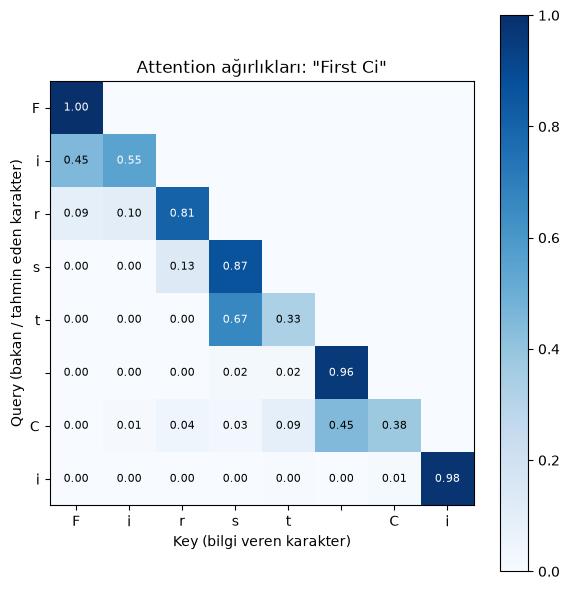

In [61]:
fig, ax = plt.subplots(figsize=(6, 6))
im = ax.imshow(wei_matrix.detach().numpy(), cmap='Blues')

ax.set_xticks(range(block_size))
ax.set_xticklabels(chars_in_example)
ax.set_yticks(range(block_size))
ax.set_yticklabels(chars_in_example)
ax.set_xlabel("Key (bilgi veren karakter)")
ax.set_ylabel("Query (bakan / tahmin eden karakter)")

for i in range(block_size):
    for j in range(block_size):
        val = wei_matrix[i, j].item()
        if val > 0:
            ax.text(j, i, f"{val:.2f}", ha='center', va='center',
                     color='white' if val > 0.5 else 'black', fontsize=8)

plt.colorbar(im)
plt.title(f"Attention ağırlıkları: \"{''.join(chars_in_example)}\"")
plt.tight_layout()
plt.show()